In [37]:
import json
import pandas as pd
import numpy as np
from pathlib import Path

# Load the results
RESULTS_FILE = "grid_search_results_default_100.json"

with open(RESULTS_FILE) as f:
    data = json.load(f)

print(f"Loaded results from: {RESULTS_FILE}")
print(f"Timestamp: {data['timestamp']}")
print(f"Number of folds: {data['n_folds']}")
print(f"Number of experiments: {len(data['results'])}")
print(f"Use SHAP: {data['use_shap']}")
print(f"Use LightGBM defaults: {data['use_lightgbm_default']}")


Loaded results from: grid_search_results_default_100.json
Timestamp: 2025-12-12T15:28:06.878004
Number of folds: 10
Number of experiments: 72
Use SHAP: False
Use LightGBM defaults: True


## Convert to DataFrame

Create a summary dataframe with mean and std of metrics across folds for each parameter configuration.


In [38]:
# Build summary dataframe
rows = []
for exp in data['results']:
    params = exp['full_params']
    fold_results = exp['fold_results']
    
    train_mses = [f['train_mse'] for f in fold_results]
    test_mses = [f['test_mse'] for f in fold_results]
    
    row = {
        # Parameters (only varying ones)
        'drop_rate': params.get('drop_rate'),
        'feature_fraction_bynode': params.get('feature_fraction_bynode'),
        'learning_rate': params.get('learning_rate'),
        'num_leaves': params.get('num_leaves'),
        'max_depth': params.get('max_depth'),
        # Metrics
        'train_mse_mean': np.mean(train_mses),
        'train_mse_std': np.std(train_mses),
        'test_mse_mean': np.mean(test_mses),
        'test_mse_std': np.std(test_mses),
        'test_mse_min': np.min(test_mses),
        'test_mse_max': np.max(test_mses),
        # Overfitting indicator
        'overfit_ratio': np.mean(test_mses) / np.mean(train_mses),
    }
    rows.append(row)

df = pd.DataFrame(rows)
print(f"Summary dataframe shape: {df.shape}")
df.head(10)


Summary dataframe shape: (72, 12)


,drop_rate,feature_fraction_bynode,learning_rate,num_leaves,max_depth,train_mse_mean,train_mse_std,test_mse_mean,test_mse_std,test_mse_min,test_mse_max,overfit_ratio
0,0.025,0.2,0.1,50,10,61.492923,1.574074,95.069686,21.989882,62.041962,138.516352,1.546026
1,0.025,0.2,0.1,100,10,59.799524,1.551585,97.086835,24.282832,61.822556,135.885101,1.623539
2,0.025,0.2,0.1,200,10,59.288989,1.607180,95.408273,21.848739,60.427811,134.022318,1.609207
3,0.025,0.2,0.2,50,10,13.690038,0.260608,48.894179,18.534001,20.911524,83.591256,3.571515
4,0.025,0.2,0.2,100,10,12.471625,0.333138,48.275449,18.373197,21.367753,81.942632,3.870823
5,0.025,0.2,0.2,200,10,12.107832,0.305813,49.379762,15.751464,24.081632,75.833804,4.078332
6,0.025,0.2,0.3,50,10,4.077048,0.094200,40.511615,15.428130,17.968433,65.076088,9.936506
7,0.025,0.2,0.3,100,10,2.973651,0.088316,38.331014,15.686312,16.436531,64.603380,12.890217
8,0.025,0.2,0.3,200,10,2.611650,0.063539,39.326529,14.170315,20.287774,71.194581,15.058113
9,0.025,0.4,0.1,50,10,61.007216,1.562671,97.311852,23.002891,60.669919,137.837103,1.595088


## Overall Statistics


In [39]:
df[['train_mse_mean', 'test_mse_mean', 'test_mse_std', 'overfit_ratio']].describe()


,train_mse_mean,test_mse_mean,test_mse_std,overfit_ratio
count,72.000000,72.000000,72.000000,72.000000
mean,20.229996,55.562007,18.258018,6.861575
std,21.054527,21.457451,3.551053,5.655120
min,1.561312,35.358005,13.207273,1.533555
25%,3.532222,38.912564,15.569456,1.942570
50%,10.062389,45.833547,16.879277,4.416971
75%,35.778614,70.644039,21.246427,11.268129
max,61.492923,99.350003,26.033422,24.000077


## Best Configurations

Top 10 configurations ranked by mean test MSE (lower is better).


In [40]:
best_configs = df.sort_values('test_mse_mean').head(10)
best_configs[['drop_rate', 'feature_fraction_bynode', 'learning_rate', 'num_leaves', 
              'test_mse_mean', 'test_mse_std', 'train_mse_mean', 'overfit_ratio']]


,drop_rate,feature_fraction_bynode,learning_rate,num_leaves,test_mse_mean,test_mse_std,train_mse_mean,overfit_ratio
43,0.10,0.2,0.3,100,35.358005,14.788289,2.063120,17.138121
44,0.10,0.2,0.3,200,35.733257,15.135535,1.739290,20.544734
52,0.10,0.4,0.3,100,35.744914,13.438266,1.853962,19.280283
70,0.20,0.4,0.3,100,35.940688,13.623473,2.895168,12.414024
60,0.20,0.2,0.3,50,36.393815,13.520218,4.384257,8.301023
42,0.10,0.2,0.3,50,36.543170,15.510389,3.252190,11.236479
62,0.20,0.2,0.3,200,36.564358,15.001490,2.782614,13.140291
51,0.10,0.4,0.3,50,36.823841,15.813379,2.883319,12.771336
69,0.20,0.4,0.3,50,36.867453,14.964914,4.035549,9.135672
34,0.05,0.4,0.3,100,37.057846,13.822443,2.646437,14.002918


## Worst Configurations

Bottom 10 configurations ranked by mean test MSE.


In [41]:
worst_configs = df.sort_values('test_mse_mean', ascending=False).head(10)
worst_configs[['drop_rate', 'feature_fraction_bynode', 'learning_rate', 'num_leaves', 
               'test_mse_mean', 'test_mse_std', 'train_mse_mean', 'overfit_ratio']]


,drop_rate,feature_fraction_bynode,learning_rate,num_leaves,test_mse_mean,test_mse_std,train_mse_mean,overfit_ratio
10,0.025,0.4,0.1,100,99.350003,26.033422,59.446581,1.671248
9,0.025,0.4,0.1,50,97.311852,23.002891,61.007216,1.595088
1,0.025,0.2,0.1,100,97.086835,24.282832,59.799524,1.623539
11,0.025,0.4,0.1,200,96.711697,23.027614,59.042972,1.637988
2,0.025,0.2,0.1,200,95.408273,21.848739,59.288989,1.609207
0,0.025,0.2,0.1,50,95.069686,21.989882,61.492923,1.546026
64,0.200,0.4,0.1,100,93.396714,25.942105,56.576468,1.650805
63,0.200,0.4,0.1,50,93.339714,24.630808,58.801630,1.587366
55,0.200,0.2,0.1,100,92.442095,25.062223,57.014635,1.621375
65,0.200,0.4,0.1,200,92.062283,24.783409,55.816666,1.649369


## Parameter Impact Analysis

Average test MSE for each parameter value to understand which settings tend to perform better.


In [42]:
param_cols = ['drop_rate', 'feature_fraction_bynode', 'learning_rate', 'num_leaves']

print("Mean Test MSE by Parameter Value:\n")
for param in param_cols:
    grouped = df.groupby(param)['test_mse_mean'].agg(['mean', 'std', 'count'])
    grouped = grouped.sort_values('mean')
    print(f"=== {param} ===")
    print(grouped.round(2))
    print()


Mean Test MSE by Parameter Value:

=== drop_rate ===
            mean    std  count
drop_rate                     
0.100      48.01  14.10     18
0.050      54.02  17.81     18
0.200      58.20  25.16     18
0.025      62.02  25.68     18

=== feature_fraction_bynode ===
                          mean    std  count
feature_fraction_bynode                     
0.2                      55.02  21.48     36
0.4                      56.11  21.72     36

=== learning_rate ===
                mean    std  count
learning_rate                     
0.3            37.85   1.77     24
0.2            45.20   3.36     24
0.1            83.63  12.06     24

=== num_leaves ===
             mean    std  count
num_leaves                     
100         55.32  22.56     24
50          55.64  21.42     24
200         55.73  21.29     24



## Visualizations


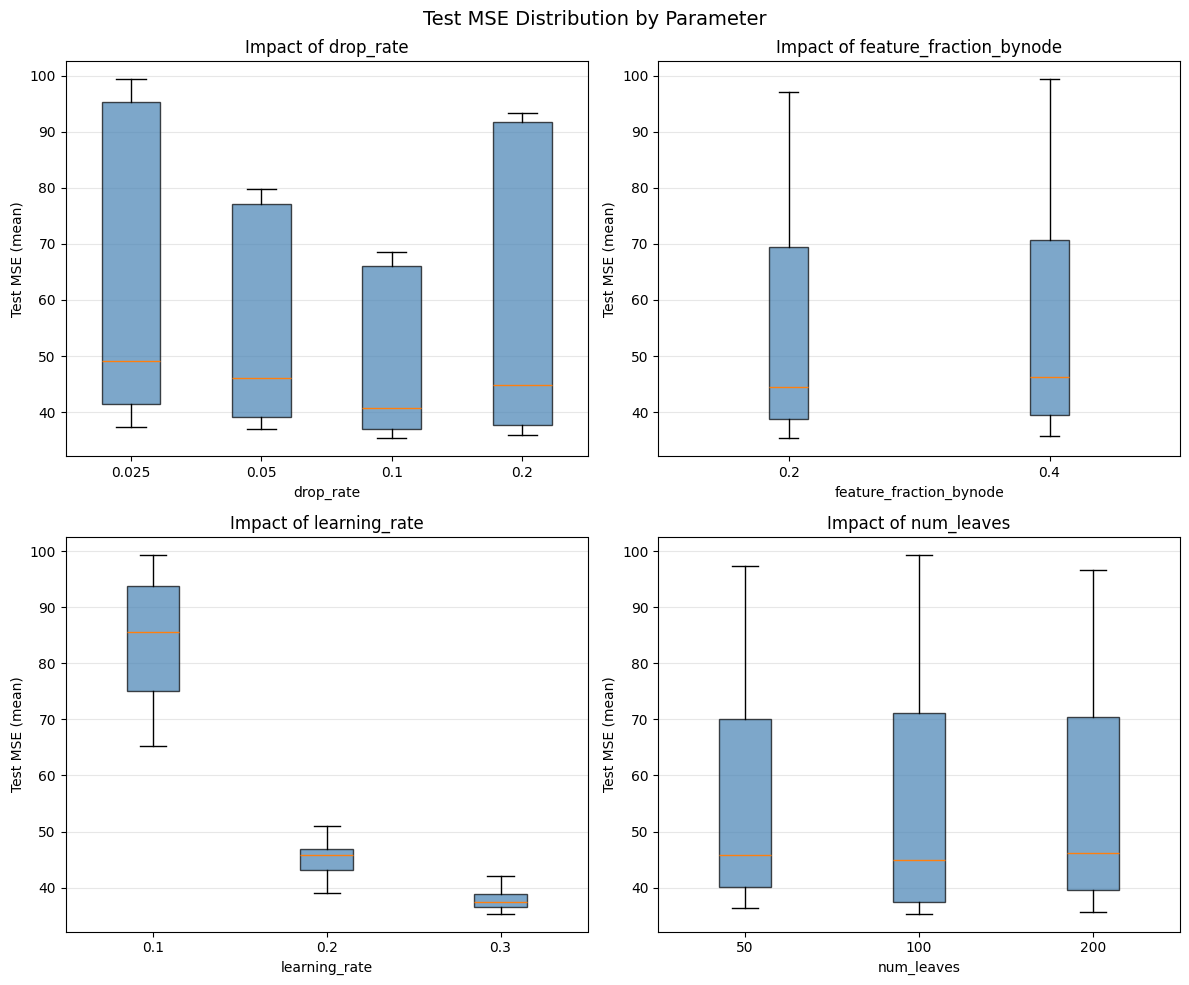

In [43]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
fig.suptitle('Test MSE Distribution by Parameter', fontsize=14)

for ax, param in zip(axes.flat, param_cols):
    grouped = df.groupby(param)['test_mse_mean'].apply(list)
    box_data = [grouped[k] for k in sorted(grouped.index)]
    labels = [str(k) for k in sorted(grouped.index)]
    
    bp = ax.boxplot(box_data, tick_labels=labels, patch_artist=True)
    for patch in bp['boxes']:
        patch.set_facecolor('steelblue')
        patch.set_alpha(0.7)
    
    ax.set_xlabel(param)
    ax.set_ylabel('Test MSE (mean)')
    ax.set_title(f'Impact of {param}')
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()


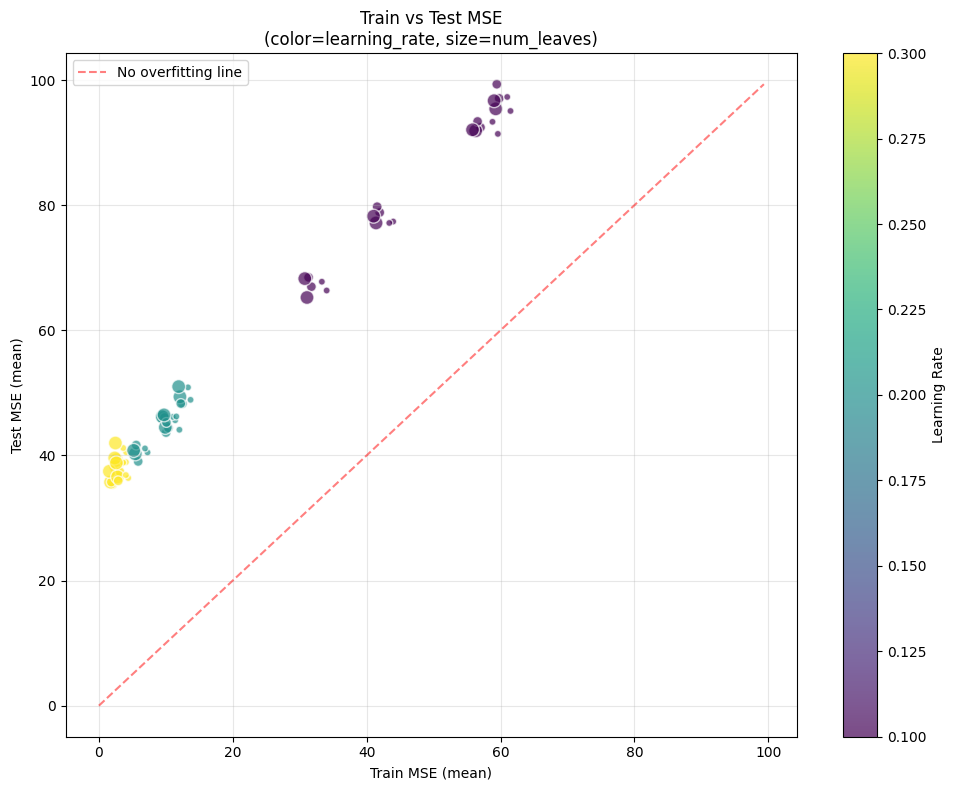

In [44]:
# Train vs Test MSE scatter plot
fig, ax = plt.subplots(figsize=(10, 8))

scatter = ax.scatter(df['train_mse_mean'], df['test_mse_mean'], 
                     c=df['learning_rate'], cmap='viridis', 
                     s=df['num_leaves']/2, alpha=0.7, edgecolors='white')

# Add diagonal line (perfect fit = no overfitting)
lims = [0, max(df['test_mse_mean'].max(), df['train_mse_mean'].max())]
ax.plot(lims, lims, 'r--', alpha=0.5, label='No overfitting line')

ax.set_xlabel('Train MSE (mean)')
ax.set_ylabel('Test MSE (mean)')
ax.set_title('Train vs Test MSE\n(color=learning_rate, size=num_leaves)')
ax.legend()
ax.grid(alpha=0.3)

cbar = plt.colorbar(scatter)
cbar.set_label('Learning Rate')

plt.tight_layout()
plt.show()


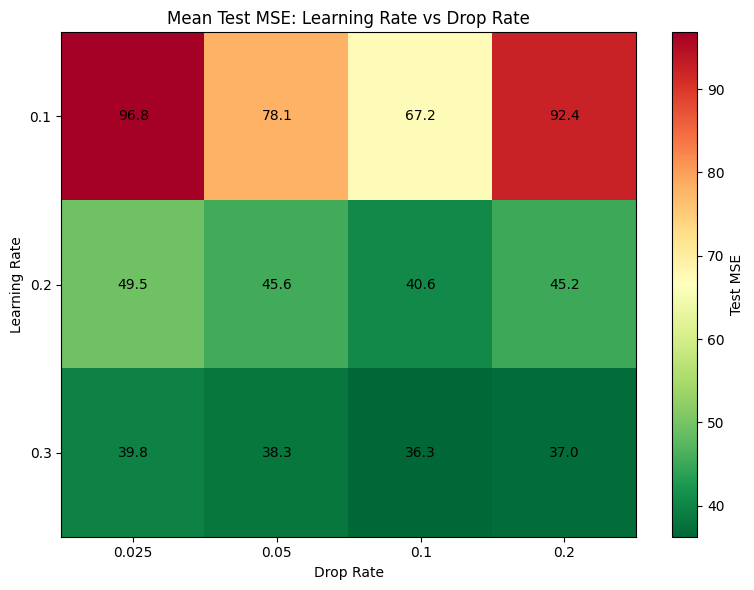

In [45]:
# Heatmap of learning_rate vs drop_rate
pivot = df.pivot_table(values='test_mse_mean', 
                       index='learning_rate', 
                       columns='drop_rate', 
                       aggfunc='mean')

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(pivot.values, cmap='RdYlGn_r', aspect='auto')

ax.set_xticks(range(len(pivot.columns)))
ax.set_yticks(range(len(pivot.index)))
ax.set_xticklabels(pivot.columns)
ax.set_yticklabels(pivot.index)
ax.set_xlabel('Drop Rate')
ax.set_ylabel('Learning Rate')
ax.set_title('Mean Test MSE: Learning Rate vs Drop Rate')

# Add values to cells
for i in range(len(pivot.index)):
    for j in range(len(pivot.columns)):
        text = ax.text(j, i, f'{pivot.values[i, j]:.1f}',
                       ha='center', va='center', color='black', fontsize=10)

plt.colorbar(im, label='Test MSE')
plt.tight_layout()
plt.show()


## Best Model Detailed Analysis

Detailed fold-by-fold results for the best configuration.


In [46]:
# Find the best model based on test_mse_mean
best_idx = df['test_mse_mean'].idxmin()
best_row = df.loc[best_idx]

# Find the corresponding raw data
best_params = {
    'drop_rate': best_row['drop_rate'],
    'feature_fraction_bynode': best_row['feature_fraction_bynode'],
    'learning_rate': best_row['learning_rate'],
    'num_leaves': best_row['num_leaves'],
}

# Find matching experiment in raw data
best_experiment = None
for exp in data['results']:
    params = exp['full_params']
    if (params.get('drop_rate') == best_params['drop_rate'] and
        params.get('feature_fraction_bynode') == best_params['feature_fraction_bynode'] and
        params.get('learning_rate') == best_params['learning_rate'] and
        params.get('num_leaves') == best_params['num_leaves']):
        best_experiment = exp
        break

print("Best Configuration Parameters:")
print("-" * 40)
for k, v in best_experiment['full_params'].items():
    print(f"  {k}: {v}")

print(f"\nOverall Performance:")
print("-" * 40)
print(f"  Mean Test MSE:  {best_row['test_mse_mean']:.4f}")
print(f"  Std Test MSE:   {best_row['test_mse_std']:.4f}")
print(f"  Mean Train MSE: {best_row['train_mse_mean']:.4f}")
print(f"  Overfit Ratio:  {best_row['overfit_ratio']:.4f}")


Best Configuration Parameters:
----------------------------------------
  objective: regression
  boosting_type: dart
  metric: mse
  verbose: -1
  max_depth: 10
  drop_rate: 0.1
  feature_fraction_bynode: 0.2
  learning_rate: 0.3
  num_leaves: 100

Overall Performance:
----------------------------------------
  Mean Test MSE:  35.3580
  Std Test MSE:   14.7883
  Mean Train MSE: 2.0631
  Overfit Ratio:  17.1381


Fold-by-Fold Results for Best Configuration:


,fold_idx,train_mse,test_mse,train_samples,test_samples,overfit_ratio
0,0,2.025596,34.308252,48493,5007,16.937362
1,1,2.054475,32.483873,49218,4282,15.811274
2,2,2.014331,57.315236,46279,7221,28.453726
3,3,1.991731,53.399529,48382,5118,26.810610
4,4,2.039314,24.541781,47063,6437,12.034332
5,5,2.203726,21.153462,46898,6602,9.598954
6,6,2.053786,21.472942,46987,6513,10.455297
7,7,2.111356,37.126052,49278,4222,17.583981
8,8,2.107183,15.216895,49183,4317,7.221439
9,9,2.029704,56.562028,49719,3781,27.867136


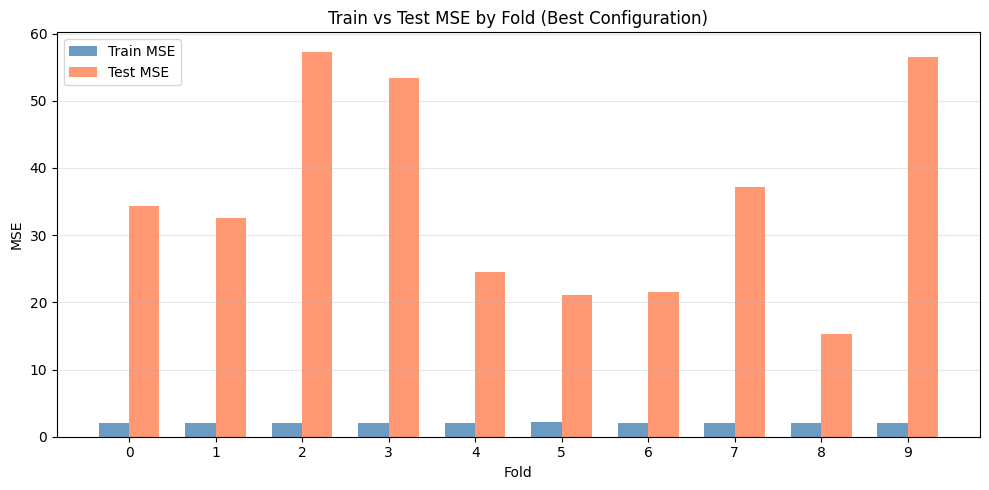

In [47]:
# Fold-level results for best model
fold_df = pd.DataFrame(best_experiment['fold_results'])
fold_df['overfit_ratio'] = fold_df['test_mse'] / fold_df['train_mse']

print("Fold-by-Fold Results for Best Configuration:")
print("=" * 60)
display(fold_df)

# Visualize fold results
fig, ax = plt.subplots(figsize=(10, 5))
x = fold_df['fold_idx']
width = 0.35

bars1 = ax.bar(x - width/2, fold_df['train_mse'], width, label='Train MSE', color='steelblue', alpha=0.8)
bars2 = ax.bar(x + width/2, fold_df['test_mse'], width, label='Test MSE', color='coral', alpha=0.8)

ax.set_xlabel('Fold')
ax.set_ylabel('MSE')
ax.set_title('Train vs Test MSE by Fold (Best Configuration)')
ax.set_xticks(x)
ax.legend()
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()


## Summary Statistics


In [48]:
print("=" * 60)
print("GRID SEARCH SUMMARY")
print("=" * 60)
print(f"\nTotal configurations tested: {len(df)}")
print(f"Cross-validation folds: {data['n_folds']}")
print(f"\nTest MSE Statistics:")
print(f"  Best:  {df['test_mse_mean'].min():.4f}")
print(f"  Worst: {df['test_mse_mean'].max():.4f}")
print(f"  Mean:  {df['test_mse_mean'].mean():.4f}")
print(f"  Std:   {df['test_mse_mean'].std():.4f}")

print(f"\nBest parameters:")
for k in ['drop_rate', 'feature_fraction_bynode', 'learning_rate', 'num_leaves']:
    print(f"  {k}: {best_row[k]}")
print("=" * 60)


GRID SEARCH SUMMARY

Total configurations tested: 72
Cross-validation folds: 10

Test MSE Statistics:
  Best:  35.3580
  Worst: 99.3500
  Mean:  55.5620
  Std:   21.4575

Best parameters:
  drop_rate: 0.1
  feature_fraction_bynode: 0.2
  learning_rate: 0.3
  num_leaves: 100.0
